In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Levins Model


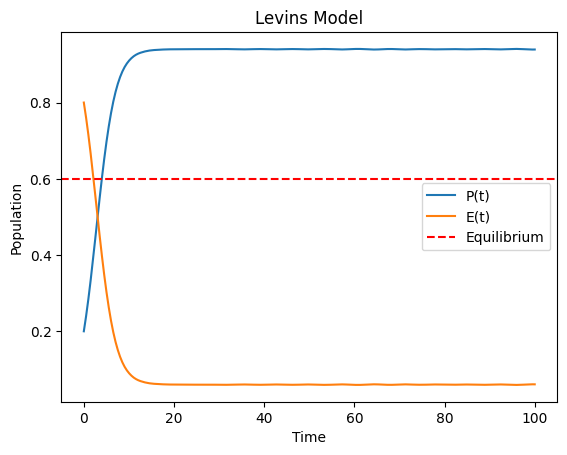

In [4]:
def LevinsModel_deterministic(t, y):
    # Parameters
    settlement_c = 0.5
    extintion_e = 0.03

    # Variables
    P = y[0]
    
    # Equations
    dPdt = settlement_c * P * (1 - P) - extintion_e * P
    return [dPdt]

# Initial condition
y0 = [0.2]  
c = 0.5
e = 0.2
t_span = (0, 100)
t_eval = np.linspace(*t_span, 200)

# Solve the differential equation
sol = solve_ivp(LevinsModel_deterministic, t_span, y0, t_eval=t_eval)
E = 1 - sol.y[0]
# Plot the solution
plt.plot(sol.t, sol.y[0], label='P(t)')

plt.plot(sol.t, E, label='E(t)')
# plot una retta orizzontale in y = 1 - e/c  (l'equilibrio)
plt.axhline(y= ((c-e)/c), color='r', linestyle='--', label='Equilibrium')
plt.title('Levins Model')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.show()


In [5]:
def LevinsMap(e, c, P):
    return c * P * (1 - P) - e * P

def ComputeLevinsModel(x0, e, c, iterations):
    x = x0
    y = [x]
    for i in range(iterations):
        new_x = x + LevinsMap(e, c, x)
        x = new_x
        y.append(x)
    return y

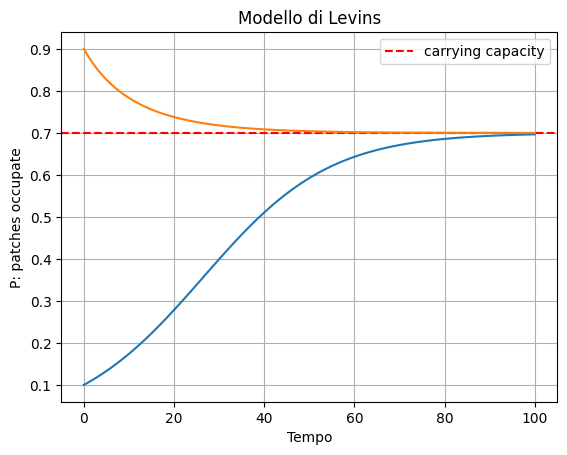

In [6]:
iterations = 100
x0 = 0.1
e = 0.03
c = 0.1
y = ComputeLevinsModel(x0, e, c, iterations)
y2 = ComputeLevinsModel(0.9, e, c, iterations)

plt.axhline(y= ((c-e)/c), color='r', linestyle='--', label='carrying capacity')
plt.plot(y)
plt.plot(y2)
plt.title('Modello di Levins')
plt.xlabel('Tempo')
plt.ylabel('P: patches occupate')
plt.legend()
plt.grid("true")
plt.show()


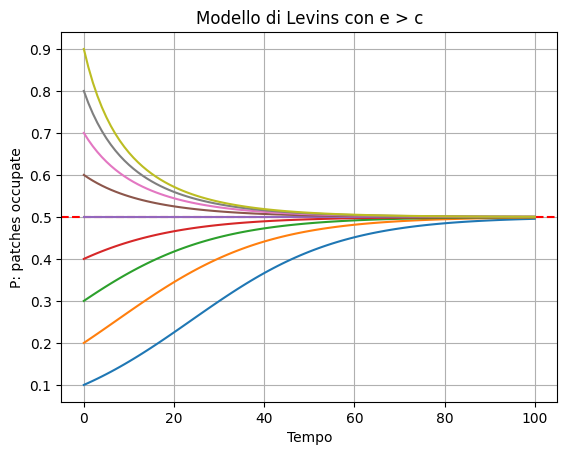

In [7]:
iterations = 100
x0 = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
e = 0.06
c = 0.12

plt.axhline(y= (c-e)/c, color='r', linestyle='--', label='carrying capacity')
for i in x0:
    y = ComputeLevinsModel(i, e, c, iterations)
    plt.plot(y)
plt.title('Modello di Levins con e > c')
plt.xlabel('Tempo')
plt.ylabel('P: patches occupate')
plt.grid("true")
plt.show()


In [8]:
def plot_derivative_sign(c, e):

    # Caso 1: c > e (equilibrio positivo)
    if c > e:
        # Punto di equilibrio
        P_star = 1 - e / c  # Equilibrio stabile se c > e

        # Definiamo l'intervallo di P
        P_vals = np.linspace(0, 1, 100)
        dPdt_vals = c * P_vals * (1 - P_vals) - e * P_vals  # Equazione di Levins

        # Creazione del grafico
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(P_vals, dPdt_vals, label=r'$\frac{dP}{dt}$', color='black')
        ax.axhline(0, color='gray', linestyle='--')  # Linea orizzontale per dP/dt = 0
        ax.axvline(P_star, color='red', linestyle=':', label=r'$P^* = 1 - \frac{e}{c}$')  # Punto di equilibrio

        # Aggiunta delle frecce per la direzione del cambiamento
        for P in np.linspace(0.05, 0.95, 8):  # Posizioni delle frecce
            dPdt = c * P * (1 - P) - e * P
            if dPdt > 0:
                ax.annotate("", xy=(P + 0.05, 0), xytext=(P, 0.0),
                            arrowprops=dict(arrowstyle="->", color="red", lw=1.5))
            else:
                ax.annotate("", xy=(P - 0.05, 0), xytext=(P, 0.0),
                            arrowprops=dict(arrowstyle="->", color="blue", lw=1.5))

        # Etichette e legenda
        ax.set_xlim(0, 1)  # Solo valori validi di P
        ax.set_xlabel("Frazione di habitat occupati (P)")
        ax.set_ylabel(r'$\frac{dP}{dt}$')
        ax.legend()
        ax.set_title("Dinamica del modello con segno della derivata (c > e)")
        plt.grid()
        plt.show()

    # Caso 2: c <= e (estinzione della popolazione)
    else:
        P_vals = np.linspace(0, 1, 100)
        dPdt_vals = c * P_vals * (1 - P_vals) - e * P_vals  # Equazione di Levins

        # Creazione del grafico
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(P_vals, dPdt_vals, label=r'$\frac{dP}{dt}$', color='black')
        ax.axhline(0, color='gray', linestyle='--')  # Linea orizzontale per dP/dt = 0
        
        # Aggiunta delle frecce (solo se rimangono nel dominio valido)
        for P in np.linspace(0.05, 1, 8):  # Posizioni delle frecce
            dPdt = c * P * (1 - P) - e * P
            if dPdt < 0 and P - 0.05 >= 0:  # Assicuriamoci che P-0.05 non sia negativo
                ax.annotate("", xy=(P - 0.05, 0), xytext=(P, 0.0),
                            arrowprops=dict(arrowstyle="->", color="blue", lw=1.5))
        
        # Etichette e legenda
        ax.set_xlim(0, 1)  # Solo valori validi di P
        ax.set_xlabel("Frazione di habitat occupati (P)")
        ax.set_ylabel(r'$\frac{dP}{dt}$')
        ax.legend()
        ax.set_title("Dinamica del modello con segno della derivata (c ≤ e)")
        plt.grid()
        plt.show()

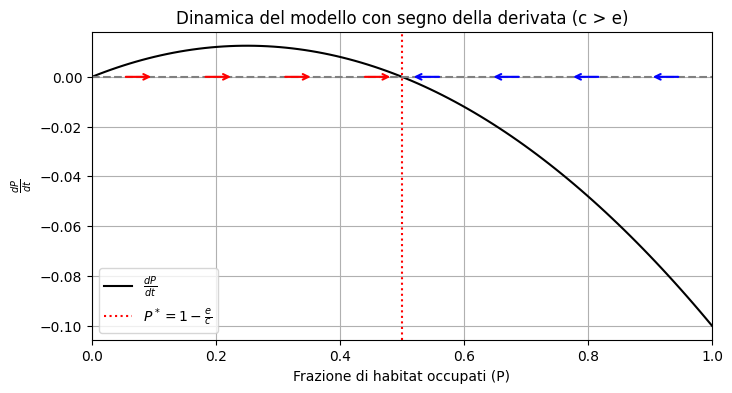

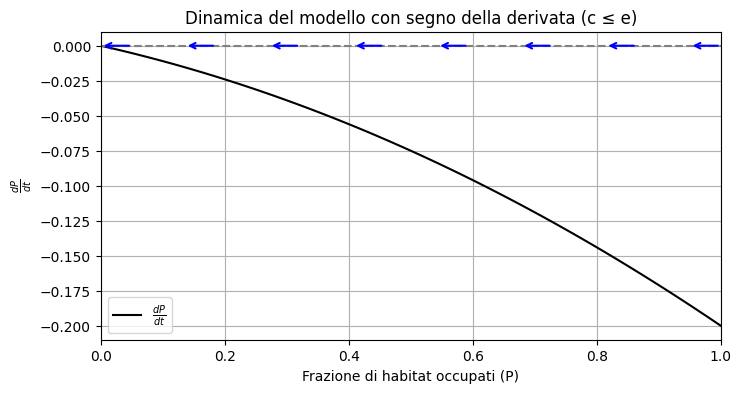

In [9]:
plot_derivative_sign(0.2, 0.1)
plot_derivative_sign(0.1, 0.2)

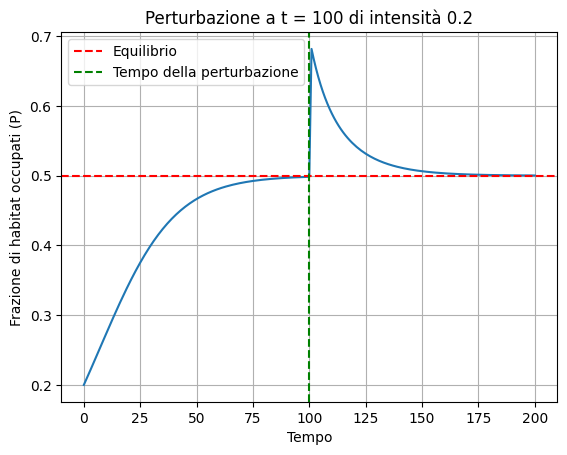

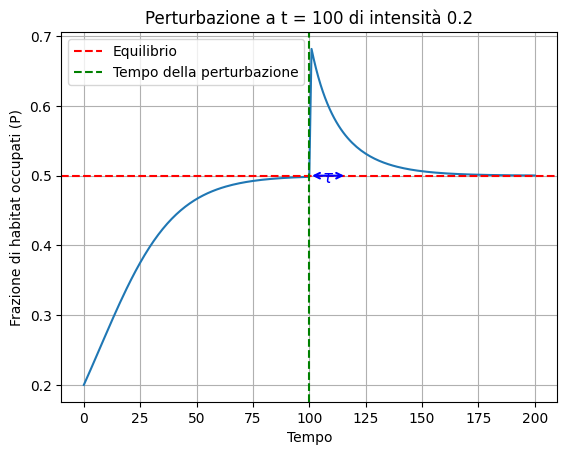

In [10]:
def ComputeLogisticModel_perturbed(x0, e, c, iterations, perturbation_t, p_magnitude):
    x = x0
    y = [x]
    for i in range(iterations):
        if i == perturbation_t:
            x = x + p_magnitude
        new_x = x + LevinsMap(e, c, x)
        x = new_x
        y.append(x)
    return y

iterations = 200
x0 = 0.2
e = 0.06
c = 0.12
perturbation_t = 100
p_magnitude = 0.2
y = ComputeLogisticModel_perturbed(x0, e, c, iterations, perturbation_t, p_magnitude)

tempo_caratteristico = 1 / (c - e)
t_tau = perturbation_t + tempo_caratteristico

plt.plot(y)
plt.title(f'Perturbazione a t = {perturbation_t} di intensità {p_magnitude}')
plt.axhline(1 - e / c, 0, iterations, color='r', linestyle='--', label='Equilibrio')
plt.axvline(perturbation_t, color='g', linestyle='--', label='Tempo della perturbazione')
plt.xlabel('Tempo')
plt.ylabel('Frazione di habitat occupati (P)')
plt.legend()
plt.grid()
plt.show()


plt.plot(y)
plt.title(f'Perturbazione a t = {perturbation_t} di intensità {p_magnitude}')
plt.axhline(1 - e / c, color='r', linestyle='--', label='Equilibrio')
plt.axvline(perturbation_t, color='g', linestyle='--', label='Tempo della perturbazione')

plt.annotate('', xy=(perturbation_t, 0.5), xytext=(t_tau, 0.5),
             arrowprops=dict(arrowstyle='<->', color='blue', lw=1.5))
plt.text((perturbation_t + t_tau) / 2, 0.49, r'$\tau$', color='blue', fontsize=12, ha='center')

# Etichette e legenda
plt.xlabel('Tempo')
plt.ylabel('Frazione di habitat occupati (P)')
plt.legend()
plt.grid()
plt.show()


In [11]:
tempo_caratteristico

16.666666666666668

## Verifichiamo che 0 sia un punto di equilibrio instabile con (e < c)

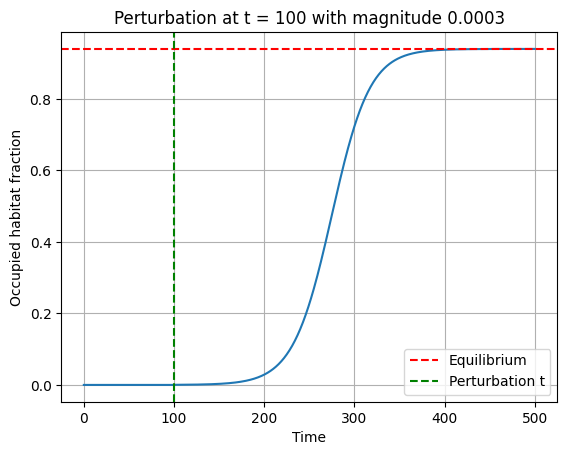

In [12]:
iterations = 500
x0 = 0
e = 0.003
c = 0.05
perturbation_t = 100
p_magnitude = 0.0003

y = ComputeLogisticModel_perturbed(x0, e, c, iterations, perturbation_t, p_magnitude)

tempo_caratteristico = 1 / (c - e)
t_tau = perturbation_t + tempo_caratteristico

plt.plot(y)
plt.title(f'Perturbation at t = {perturbation_t} with magnitude {p_magnitude}')
plt.axhline(1 - e / c, 0, iterations, color='r', linestyle='--', label='Equilibrium')
plt.axvline(perturbation_t, color='g', linestyle='--', label='Perturbation t')
plt.xlabel('Time')
plt.ylabel('Occupied habitat fraction')
plt.legend()
plt.grid()
plt.show()

----

# 3-state Metapopulation model

In [38]:
# Definizione delle equazioni differenziali del modello
def dE_dt(E, L, e_S, c):
    return e_S * (1 - E - L) - c * E * L

def dL_dt(E, L, r, m, e_L):
    return (r + m * L) * (1 - E - L) - e_L * L

# Funzione che definisce il limite teorico L = 1 - E
def limit_line(x):
    return 1 - x

def plot_phase_plane(e_S, c, r, m, e_L):
    # Creazione della griglia per E e L
    E_vals = np.linspace(0, 1, 20)  # Ridotto per migliorare la visualizzazione di quiver
    L_vals = np.linspace(0, 1, 20)
    E, L = np.meshgrid(E_vals, L_vals)

    # Calcolo delle derivate
    dE = dE_dt(E, L, e_S, c)
    dL = dL_dt(E, L, r, m, e_L)

    # Normalizzazione per evitare frecce troppo lunghe
    magnitude = np.sqrt(dE**2 + dL**2)
    dE /= magnitude
    dL /= magnitude

    E_fine = np.linspace(0, 1, 200)  # Risoluzione più alta per il limite teorico
    limit = limit_line(E_fine)

    # Creazione della figura con due subplot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- PRIMO GRAFICO: Nullclines ---
   

    CS1 = axes[0].contour(E, L, dE_dt(E, L, e_S, c), levels=[0], colors='blue', linewidths=2)
    CS2 = axes[0].contour(E, L, dL_dt(E, L, r, m, e_L), levels=[0], colors='red', linewidths=2)

    # Etichette per le nullclines
    axes[0].clabel(CS1, inline=1, fontsize=10, fmt='dE/dt=0')
    axes[0].clabel(CS2, inline=1, fontsize=10, fmt='dL/dt=0')

    # Limite teorico della somma delle variabili
    axes[0].plot(E_fine, limit, 'k--', label='Limite teorico $E + L + S = 1$')

    axes[0].set_xlabel('E (frequenza di patch vuote)')
    axes[0].set_ylabel('L (frequenza di patch con grande popolazione)')
    axes[0].set_title('Equilibri del modello di Hanski')
    axes[0].grid(True)
    axes[0].legend()

    # --- SECONDO GRAFICO: Direzione del flusso ---
    axes[1].contour(E, L, dE_dt(E, L, e_S, c), levels=[0], colors='blue', linewidths=2)
    axes[1].contour(E, L, dL_dt(E, L, r, m, e_L), levels=[0], colors='red', linewidths=2)
    axes[1].plot(E_fine, limit, 'k--', label='Limite teorico $E + L = 1$')
    axes[1].quiver(E, L, dE, dL, color='black', alpha=0.8)
    axes[1].set_xlabel('E (frequenza di patch vuote)')
    axes[1].set_ylabel('L (frequenza di patch con grande popolazione)')
    axes[1].set_title('Campo vettoriale nel piano di fase')
    axes[1].grid(True)

    # Layout per una migliore visualizzazione
    plt.tight_layout()
    plt.show()

def computeHanski_model(e_S, c, r, m, e_L, E0, L0, t_span, t_eval):
    def HanskiModel(t, y):
        E, L = y
        dEdt = dE_dt(E, L, e_S, c)
        dLdt = dL_dt(E, L, r, m, e_L)
        return [dEdt, dLdt]
    
    # Risoluzione del sistema di equazioni differenziali
    sol = solve_ivp(HanskiModel, t_span, [E0, L0], t_eval=t_eval)

    E_vec = sol.y[0]
    L_vec = sol.y[1]
    S_vec = 1 - E_vec - L_vec

    return sol.t, E_vec, L_vec, S_vec

def computeHanski_model_perturbation(e_S, c, r, m, e_L, E0, L0, t_span, t_eval, perturbation_t, p_magnitude):
    def HanskiModel(t, y):
        E, L = y
        dEdt = dE_dt(E, L, e_S, c)
        dLdt = dL_dt(E, L, r, m, e_L)
        return [dEdt, dLdt]
    
    t_eval_before = t_eval[t_eval < perturbation_t]
    t_eval_after = t_eval[t_eval >= perturbation_t]

    sol_before = solve_ivp(HanskiModel, (t_span[0], perturbation_t), [E0, L0], t_eval=t_eval_before)

    E_before = sol_before.y[0]
    L_before = sol_before.y[1]
    S_before = 1 - E_before - L_before

    sol_after = solve_ivp(HanskiModel, (perturbation_t, t_span[1]), [E_before[-1] + p_magnitude, L_before[-1] - p_magnitude], t_eval=t_eval_after)

    E_after = sol_after.y[0]
    L_after = sol_after.y[1]
    S_after = 1 - E_after - L_after

    t = np.concatenate((sol_before.t, sol_after.t))
    E_vec = np.concatenate((E_before, E_after))
    L_vec = np.concatenate((L_before, L_after))
    S_vec = np.concatenate((S_before, S_after))

    return t, E_vec, L_vec, S_vec


### Equilibrio di estinzione

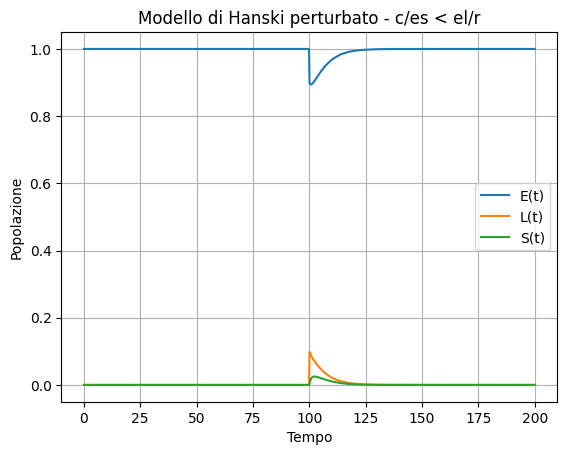

In [63]:
t_span = (0, 200)
t_eval = np.linspace(*t_span, 1000)

c, e_S = 0.2, 0.9
e_L, r = 0.2, 0.02

m   = 2.2

E01 = 1
L01 = 0

t, E1, L1, S1 = computeHanski_model_perturbation(e_S, c, r, m, e_L, E01, L01, t_span, t_eval, 100, -0.1)

plt.plot(t, E1, label='E(t)')
plt.plot(t, L1, label='L(t)')
plt.plot(t, S1, label='S(t)')
if (c/e_S) > (e_L/r):
    plt.title('Modello di Hanski perturbato - c/es > el/r')
else:
    plt.title('Modello di Hanski perturbato - c/es < el/r')
plt.xlabel('Tempo')
plt.ylabel('Popolazione')
plt.legend()
plt.grid()


C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_11048\920480461.py:24: RuntimeWarning: invalid value encountered in divide
  dE /= magnitude
C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_11048\920480461.py:25: RuntimeWarning: invalid value encountered in divide
  dL /= magnitude


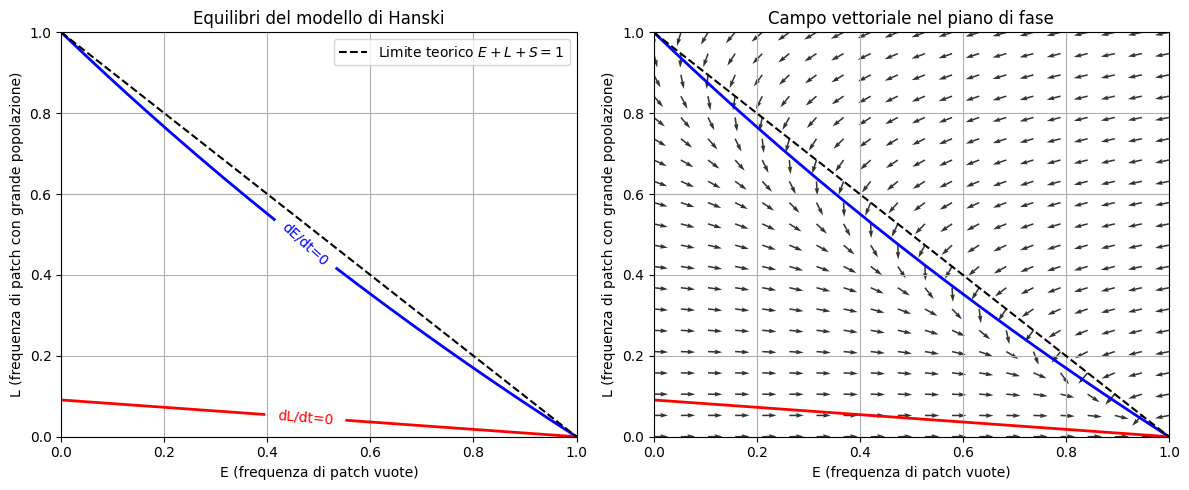

In [75]:
c, e_S = 0.2, 0.9
e_L, r = 0.2, 0.02

m   = 0

plot_phase_plane(e_S, c, r, m, e_L)

C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_11048\3076687190.py:24: RuntimeWarning: invalid value encountered in divide
  dE /= magnitude
C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_11048\3076687190.py:25: RuntimeWarning: invalid value encountered in divide
  dL /= magnitude


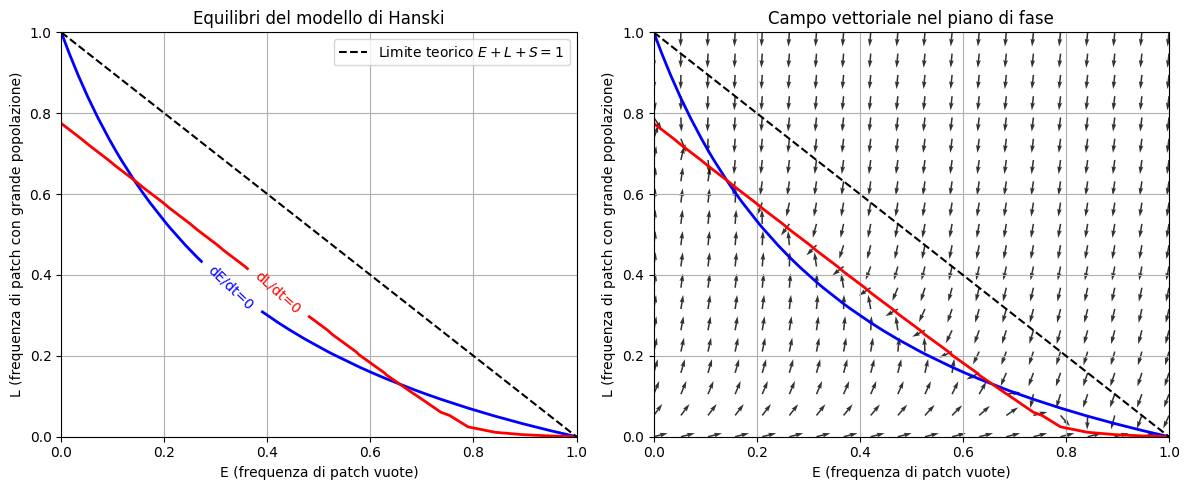

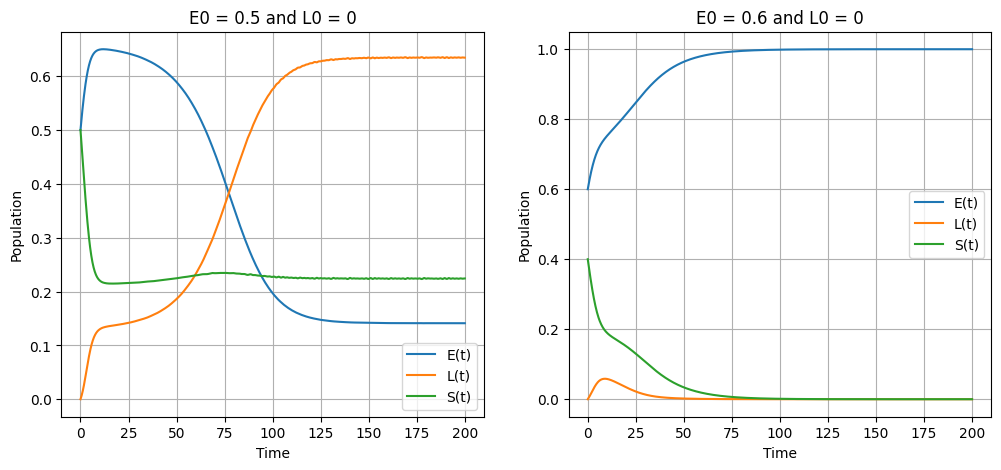

In [15]:
e_S = 0.08
c   = 0.2
r   = 0.02
m   = 2.2
e_L = 0.5

plot_phase_plane(e_S, c, r, m, e_L)

E01 = 0.5
L01 = 0
t_span = (0, 200)
t_eval = np.linspace(*t_span, 1000)


t, E1, L1, S1 = computeHanski_model(e_S, c, r, m, e_L, E01, L01, t_span, t_eval)

E02 = 0.6
L02 = 0
_, E2, L2, S2 = computeHanski_model(e_S, c, r, m, e_L, E02, L02, t_span, t_eval)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(t, E1, label='E(t)')
ax[0].plot(t, L1, label='L(t)')
ax[0].plot(t, S1, label='S(t)')
ax[0].set_xlabel('Time')
ax[0].set_ylabel('Population')
ax[0].set_title('E0 = 0.5 and L0 = 0')
ax[0].legend()
ax[0].grid()

ax[1].plot(t, E2, label='E(t)')
ax[1].plot(t, L2, label='L(t)')
ax[1].plot(t, S2, label='S(t)')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Population')
ax[1].set_title('E0 = 0.6 and L0 = 0')
ax[1].legend()
ax[1].grid()


## Biforcazione

Plotto i 2 diversi casi: 1 solo equilbrio vs 2

C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_11048\3076687190.py:24: RuntimeWarning: invalid value encountered in divide
  dE /= magnitude
C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_11048\3076687190.py:25: RuntimeWarning: invalid value encountered in divide
  dL /= magnitude


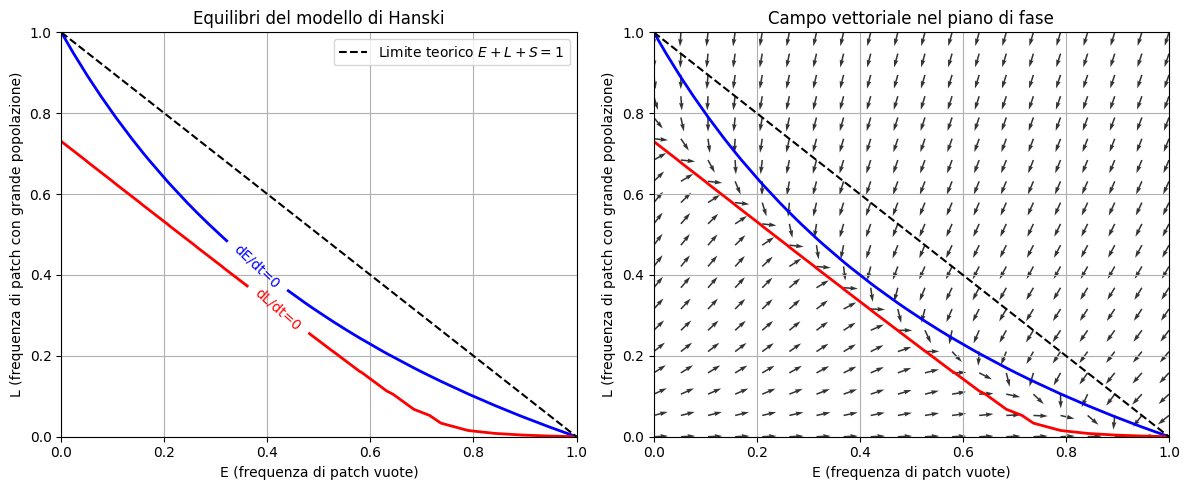

In [16]:
# c/eS < eL/r --> un solo equilibrio 

e_S = 0.4
c   = 0.5
r   = 0.02
m   = 2.2
e_L = 0.6

plot_phase_plane(e_S, c, r, m, e_L)

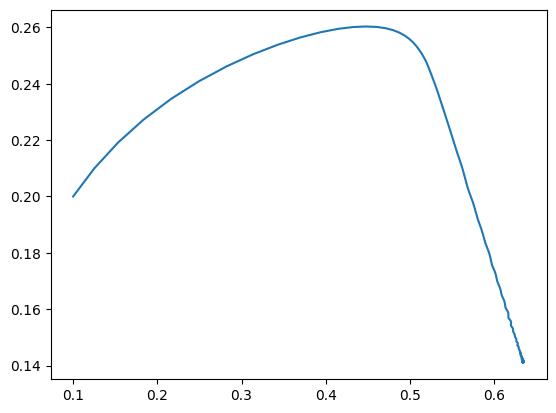

In [17]:
e_S = 0.08
c   = 0.2
r   = 0.02
m   = 2.2
e_L = 0.5

E0 = 0.2
L0 = 0.1
_, E, L, S = computeHanski_model(e_S, c, r, m, e_L, E0, L0, t_span, t_eval)

plt.plot(L, E, label='E(t)')

C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_11048\3076687190.py:24: RuntimeWarning: invalid value encountered in divide
  dE /= magnitude
C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_11048\3076687190.py:25: RuntimeWarning: invalid value encountered in divide
  dL /= magnitude


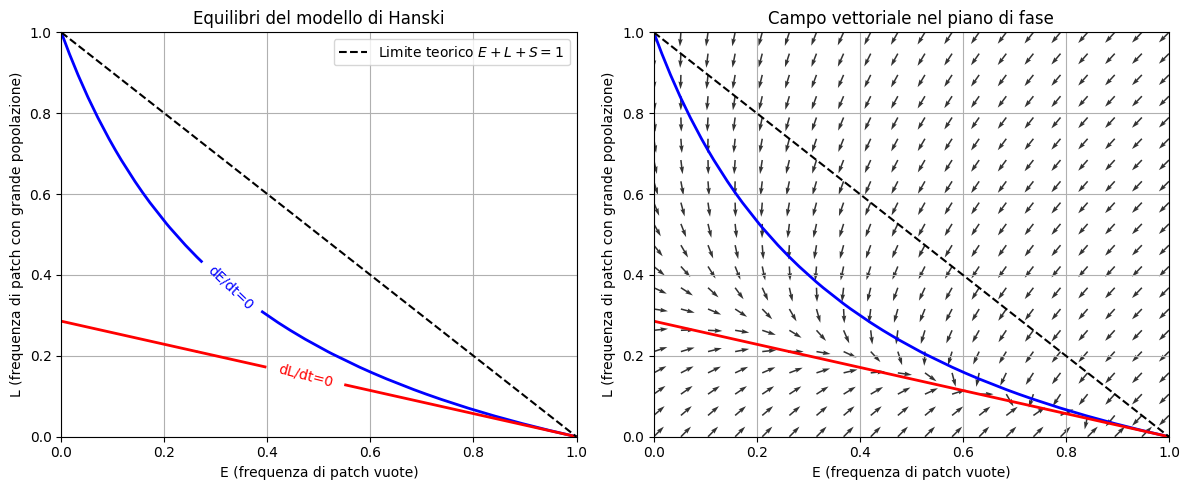

In [24]:
# caso c/eS = eL/r

e_S = 0.08
c   = 0.2
r   = 0.08
m   = 0
e_L = 0.2

plot_phase_plane(e_S, c, r, m, e_L)